---
authors:
  - name: Javier Marchena-Hurtado
  - name: Daniel Strobl
  - name: Ciro Ramírez-Suástegui
  - name: Lukas Heumos
    roles:
      - writing – review & editing
  - name: Anna Schaar
    roles:
      - writing – review & editing
---


(surface-protein-batch-correction)=
# Batch correction
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #surface-protein-batch-correction-key-takeaway-1
Due to pronounced batch effects in ADT data, methods like Harmony, originally designed for transcriptomics data, are recommended for batch correction, as they effectively integrate samples and maintain cell type separation.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} surface_protein.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(surface-protein-batch-correction-key-takeaway-1)=
## Motivation

As could be seen for our earlier visualized ADT data, batch effects between donors are very pronounced (see [Dimensionality Reduction](#surface-protein-dimensionality-reduction)). 
Hence, batch correction to mitigate this effect is required.

We use Harmony here. 
There is no benchmarking of different batch correction methods for ADT data. 
We therefore use Harmony, a method that has been benchmarked for scRNA-seq data with good results.

Recently two batch correction methods for ADT data have been published in reputable journals and/or by reputable authors: ADTnorm {cite:p}`sp:zheng2025adtnorm` and CytoVI {cite:p}`sp:ingelfinger2025cytovi`. 
These two methods might be appropriate for ADT data. 
However, as mentioned, here we stick to Harmony, which is more proven and independently benchmarked (although for transcriptomics and not for ADT data).

## Environment setup

In [1]:
import warnings

import scanpy as sc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
sc.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

import lamindb as ln

ln.track()

→ connected lamindb: theislab/sc-best-practices
→ found notebook batch_correction.ipynb, making new version -- anticipating changes
→ created Transform('4LJehi0GPRuj0006', key='batch_correction.ipynb'), started new Run('nxVysIoDJ9QSryHS') at 2026-07-29 11:11:33 UTC
→ notebook imports: lamindb-core==2.3.1 muon==0.1.9 scanpy==1.12.3
• recommendation: to identify the notebook across renames, pass the uid: ln.track("4LJehi0GPRuj")


## Loading the data

We load the MuData object we saved at the end of the previous chapter, [Dimensionality Reduction](#surface-protein-dimensionality-reduction):

In [2]:
af = ln.Artifact.connect("theislab/sc-best-practices").get(
    key="surface-protein/cite_dimensionality_reduction.h5mu", is_latest=True
)
mdata = af.load()
mdata

MuData object with n_obs × n_vars = 105907 × 36737
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
  2 modalities
    rna:	105907 × 36601
      obs:	'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'outliers'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    prot:	105907 × 136
      obs:	'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'outliers', 'doublets_markers'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'batch_colors', 'donor_colors', 'doublets_markers_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

## Harmony

It is not yet clear which batch effect correction works best for ADT data. 
For general purposes we recommend Harmony {cite:p}`sp:Korsunsky2019` to perform batch correction of the data due to its robust performance on scRNA-seq data.

In [3]:
sc.external.pp.harmony_integrate(adata=mdata["prot"], key="donor", random_state=0)

2026-07-29 13:11:39,225 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-07-29 13:11:44,476 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-29 13:11:44,822 - harmonypy - INFO - Iteration 1 of 10
2026-07-29 13:12:05,457 - harmonypy - INFO - Iteration 2 of 10
2026-07-29 13:12:26,440 - harmonypy - INFO - Iteration 3 of 10
2026-07-29 13:12:48,434 - harmonypy - INFO - Iteration 4 of 10
2026-07-29 13:13:13,239 - harmonypy - INFO - Iteration 5 of 10
2026-07-29 13:13:34,590 - harmonypy - INFO - Iteration 6 of 10
2026-07-29 13:13:55,834 - harmonypy - INFO - Iteration 7 of 10
2026-07-29 13:14:13,482 - harmonypy - INFO - Converged after 7 iterations


We now compute a neighborhood graph from the Harmony-corrected PCA and a UMAP embedding to visualize the study's variables. 

In [4]:
sc.pp.neighbors(mdata["prot"], n_pcs=20, use_rep="X_pca_harmony", random_state=0)
sc.tl.umap(mdata["prot"], random_state=0)

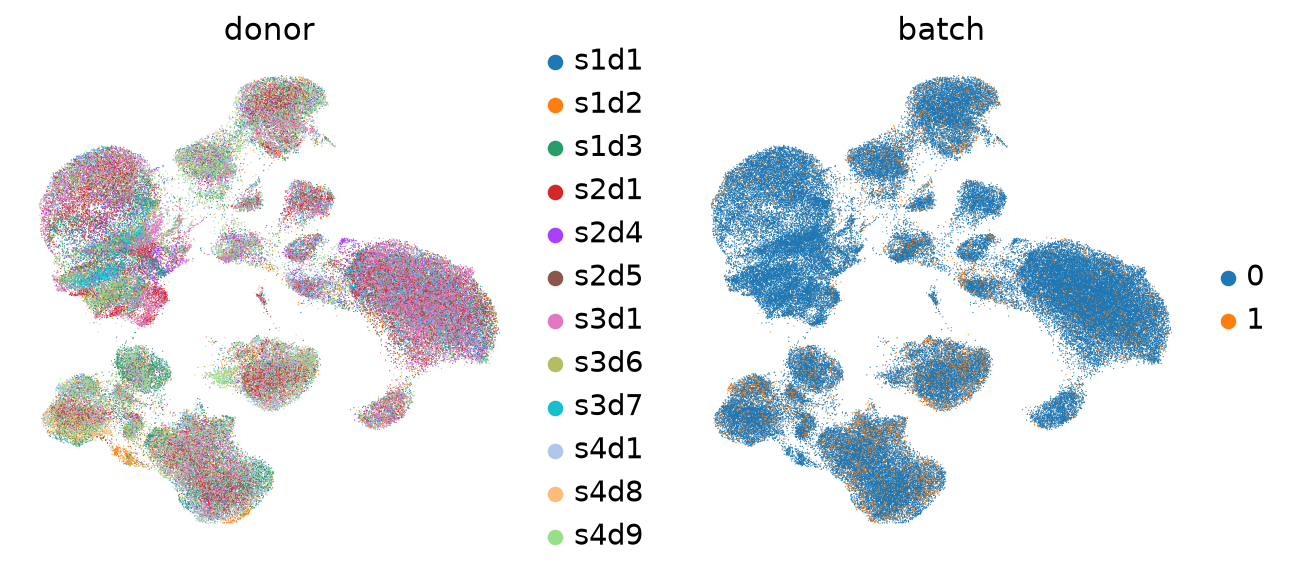

In [5]:
sc.pl.umap(mdata["prot"], color=["donor", "batch"])

As we can see here, the cells of different donors are much more intermixed in the embedding than before (see plots from the [Dimensionality Reduction](#surface-protein-dimensionality-reduction) chapter).

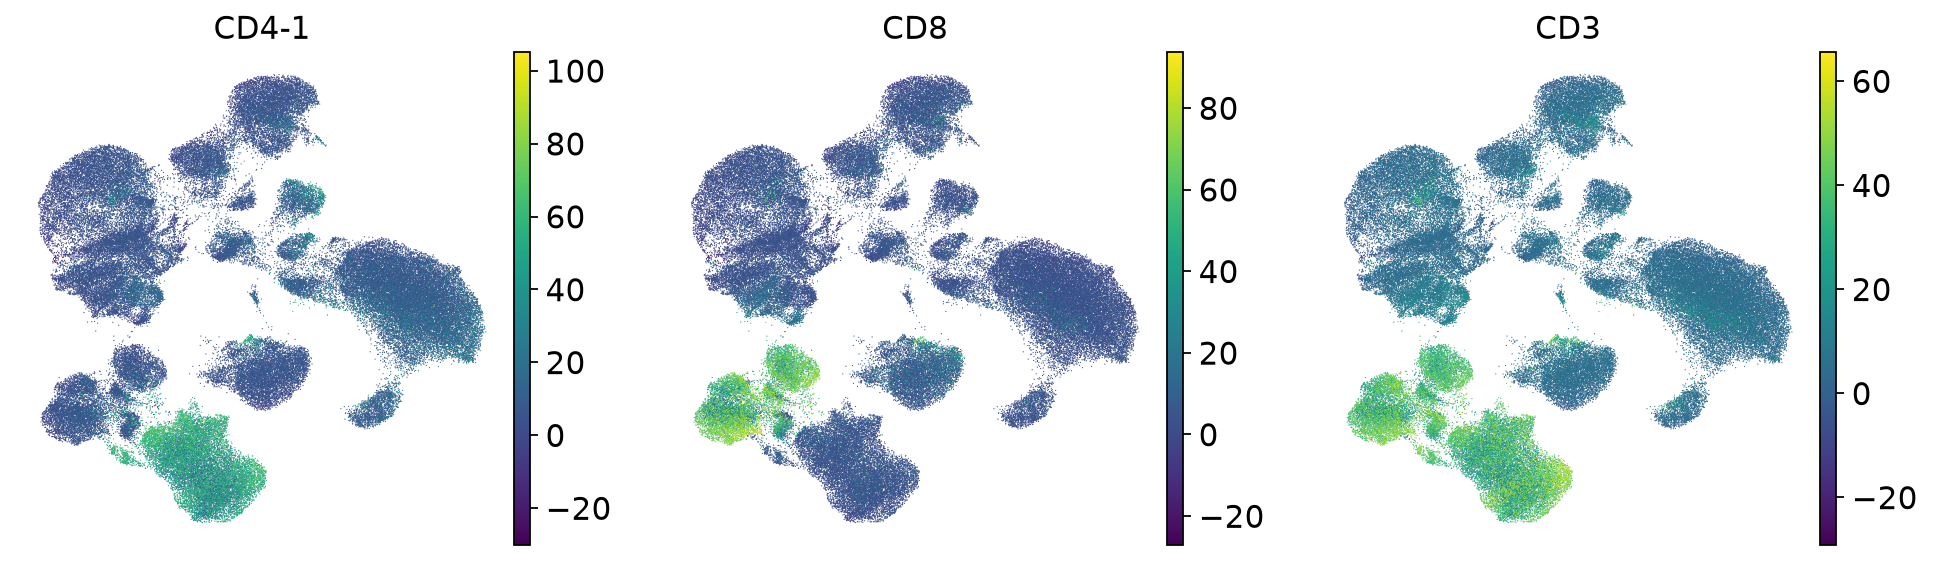

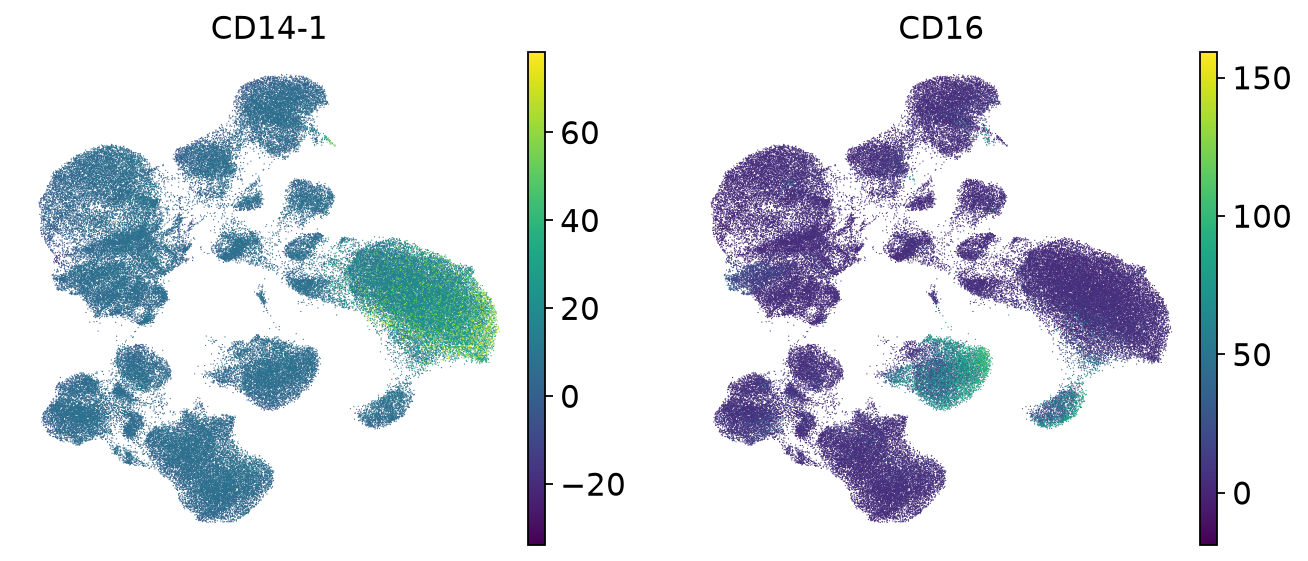

In [6]:
sc.pl.umap(mdata["prot"], color=["CD4-1", "CD8", "CD3"])
sc.pl.umap(mdata["prot"], color=["CD14-1", "CD16"])

We check the expression of a few marker genes to confirm that separate cell types are still separate from each other. 
We can see that T cells still form a separate population that is further split into CD4 and CD8 T cells. 
Additionally, unlike before batch correction, now CD4 T cells form a discrete cluster where the donors are intermingled. 
Batch correction was therefore successful.

In [7]:
af_batch_correction = ln.Artifact.from_mudata(
    mdata,
    key="surface-protein/cite_batch_correction.h5mu",
    description="CITE-seq data after batch correction",
)
af_batch_correction.save()

→ creating new artifact version for key 'surface-protein/cite_batch_correction.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'


... uploading uu6lLafald9WnYWL0006.h5mu: 100.0%
• replacing the existing cache path /var/cache/user/marchena/.cache/lamindb/lamin-eu-central-1/VPwcjx3CDAa2/surface-protein/cite_batch_correction.h5mu


Artifact(uid='uu6lLafald9WnYWL0006', key='surface-protein/cite_batch_correction.h5mu', description='CITE-seq data after batch correction', suffix='.h5mu', kind='dataset', otype='MuData', size=1449791144, hash='aYPsyP7ViUyvXh9Ss2YpzB', n_files=None, n_observations=105907, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=114, schema_id=None, created_by_id=7, created_at=2026-07-29 11:15:27 UTC, is_locked=False, version_tag=None, is_latest=True)

In [8]:
ln.finish()

• please hit CTRL + s to save the notebook in your editor .... still waiting .....
....................! please hit CTRL + s to save the notebook in your editor and re-run finish()


## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Javier Marchena-Hurtado
* Daniel Strobl
* Ciro Ramírez-Suástegui

### Reviewers

* Lukas Heumos
* Anna Schaar